In [22]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from narwhals.selectors import categorical

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,mean_squared_error
MI_NAVY="#004B8D"
MI_GOLD="#D1AB65"
MI_LIGHT="#3D8FD6"
MI_RED="#C0392B"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 11

sb.set_style("whitegrid")
pd.set_option("display.max_columns",50)
np.random.seed(42)

In [14]:
df_model=pd.read_csv("IPL_2008_-_2026-Lasso.csv")
print("shape: ",df_model.shape)
df_model.head()

shape:  (1218, 31)


,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,team2_runs,team2_wickets,winner,result_type,win_by_runs,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players,team1_wickets_remaining,team2_run_rate,total_wickets_fell,run_margin_dup,wicket_margin_dup,team2_runs_x2
0,18-04-2008,2008,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,82,10,222,3,Kolkata Knight Riders,complete,140,0,BB McCullum,J Srinath,Asad Rauf,RE Koertzen,AM Saheba,VN Kulkarni,20,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",0,11.10,13,140.0,0.0,444.0
1,19-04-2008,2008,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,207,4,240,5,Chennai Super Kings,complete,33,0,MEK Hussey,S Venkataraghavan,MR Benson,SL Shastri,RB Tiffin,MSS Ranawat,20,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",6,12.00,9,33.0,0.0,480.0
2,19-04-2008,2008,Delhi,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,132,1,129,8,Delhi Daredevils,complete,0,9,MF Maharoof,GR Viswanath,Aleem Dar,GA Pratapkumar,IL Howell,Unknown,20,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm...",9,6.45,9,0.0,9.0,258.0
3,20-04-2008,2008,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,112,5,110,10,Kolkata Knight Riders,complete,0,5,DJ Hussey,FM Engineer,BF Bowden,K Hariharan,Asad Rauf,F Gomes,20,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S...",5,5.50,15,0.0,5.0,220.0
4,20-04-2008,2008,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,165,7,166,5,Royal Challengers Bangalore,complete,0,5,MV Boucher,J Srinath,SJ Davis,DJ Harper,AV Jayaprakash,SN Bandekar,20,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli...",3,8.30,12,0.0,5.0,332.0


In [15]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     1218 non-null   str    
 1   season                   1218 non-null   str    
 2   city                     1218 non-null   str    
 3   venue                    1218 non-null   str    
 4   team1                    1218 non-null   str    
 5   team2                    1218 non-null   str    
 6   toss_winner              1218 non-null   str    
 7   toss_decision            1218 non-null   str    
 8   team1_runs               1218 non-null   int64  
 9   team1_wickets            1218 non-null   int64  
 10  team2_runs               1218 non-null   int64  
 11  team2_wickets            1218 non-null   int64  
 12  winner                   1218 non-null   str    
 13  result_type              1218 non-null   str    
 14  win_by_runs              1218 non-n

In [16]:
df_model.describe()

,team1_runs,team1_wickets,team2_runs,team2_wickets,win_by_runs,win_by_wickets,overs_limit,team1_wickets_remaining,team2_run_rate,total_wickets_fell,run_margin_dup,wicket_margin_dup,team2_runs_x2
count,1218.000000,1218.000000,1218.000000,1218.000000,1218.000000,1218.000000,1218.0,1218.000000,1218.000000,1218.000000,1218.000000,1218.000000,1218.000000
mean,166.224138,5.954844,158.112479,5.885878,14.218391,3.344007,20.0,4.045156,7.905624,11.840722,14.218391,3.344007,316.224959
std,34.885513,2.301533,32.574213,2.615160,24.020840,3.359195,0.0,2.301533,1.628711,3.053225,24.020840,3.359195,65.148426
min,58.000000,0.000000,44.000000,0.000000,0.000000,0.000000,20.0,0.000000,2.200000,3.000000,0.000000,0.000000,88.000000
25%,144.000000,4.000000,138.000000,4.000000,0.000000,0.000000,20.0,2.000000,6.900000,10.000000,0.000000,0.000000,276.000000
50%,165.000000,6.000000,160.000000,6.000000,0.000000,3.000000,20.0,4.000000,8.000000,12.000000,0.000000,3.000000,320.000000
75%,188.750000,8.000000,179.000000,8.000000,20.000000,6.000000,20.0,6.000000,8.950000,14.000000,20.000000,6.000000,358.000000
max,287.000000,10.000000,265.000000,10.000000,146.000000,10.000000,20.0,10.000000,13.250000,20.000000,146.000000,10.000000,530.000000


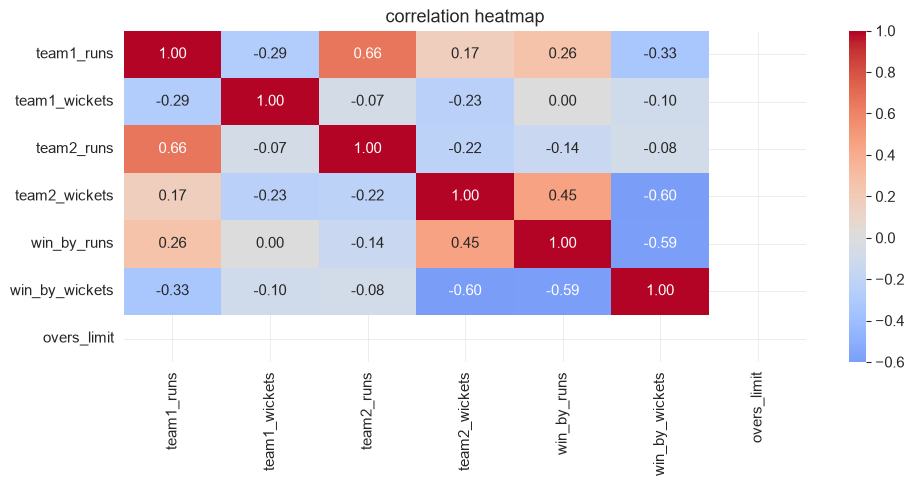

In [17]:
numeric_raw=["team1_runs","team1_wickets","team2_runs","team2_wickets","win_by_runs","win_by_wickets","overs_limit"]
fig,ax=plt.subplots(figsize=(10,5))
sb.heatmap(df_model[numeric_raw].corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0,ax=ax)
ax.set_title("correlation heatmap")
plt.tight_layout()
plt.show()

In [18]:
numeric_cols=["team1_wickets","team2_runs","team2_wickets","win_by_runs","win_by_wickets","overs_limit","team1_wickets_remaining","team2_run_rate","total_wickets_fell","run_margin_dup","wicket_margin_dup","team2_runs_x2"]
categorical_cols=["team1","team2","venue","city","toss_winner","toss_decision","season","player_of_match"]
x=pd.get_dummies(df_model[numeric_cols+categorical_cols],columns=categorical_cols,drop_first=True)
y=df_model["team1_runs"]

print("final feature matrix shape: ",x.shape)
print("number of rows: ",len(df_model))
print(f"features to rows ratio:{x.shape[1]/len(df_model):.2f}")

final feature matrix shape:  (1218, 500)
number of rows:  1218
features to rows ratio:0.41


In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
scaler=StandardScaler()
x_train_s=scaler.fit_transform(x_train)
x_test_s=scaler.fit_transform(x_test)
print("train shape : ",x_train_s.shape)
print("test shape: ",x_test_s.shape)

train shape :  (913, 500)
test shape:  (305, 500)


In [20]:
lr=LinearRegression()
lr.fit(x_train_s,y_train)
lr_train_r2=r2_score(y_train,lr.predict(x_train_s))
lr_test_r2=r2_score(y_test,lr.predict(x_test_s))
lr_gap=lr_train_r2-lr_test_r2
print(f"linear regression train r2: {lr_train_r2:.2f}")
print(f"linear regression test r2: {lr_test_r2:.2f}")
print(f"linear regression gap r2: {lr_gap:.2f}")

linear regression train r2: 0.86
linear regression test r2: 0.52
linear regression gap r2: 0.33


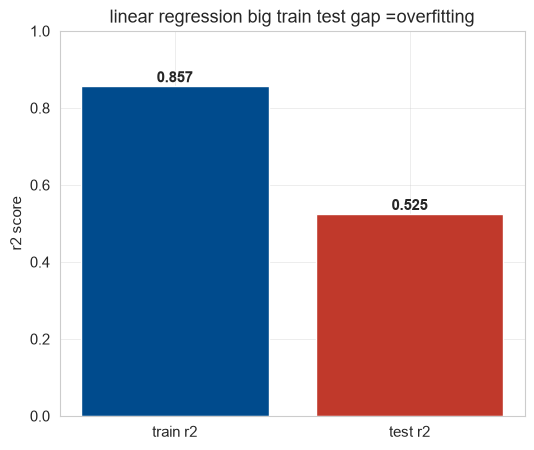

In [24]:
fig,ax=plt.subplots(figsize=(6,5))
bars=ax.bar(["train r2","test r2"],[lr_train_r2,lr_test_r2],color=[MI_NAVY,MI_RED])
for b in bars:
    ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.01,f"{b.get_height():.3f}",ha="center",fontweight="bold")
ax.set_ylim(0,1)
ax.set_title("linear regression big train test gap =overfitting")
ax.set_ylabel("r2 score")
plt.show()

In [26]:
lambdas =[0.001,0.01,0.1,1,5,10,20,50,100,200,300,500,800,1000,1500,2000,3000]
train_score,test_score=[],[]
for a in lambdas:
    lasso=Lasso(alpha=a)
    lasso.fit(x_train_s,y_train)
    train_score.append(r2_score(y_train,lasso.predict(x_train_s)))
    test_score.append(r2_score(y_test,lasso.predict(x_test_s)))
results=pd.DataFrame({
    "lambdas":lambdas,"train_r2":train_score,"test_r2":test_score
})
results["gap"]=results["train_r2"]-results["test_r2"]
print(results)

C:\Users\Tanu\PycharmProjects\libraries\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.130635e+02, tolerance: 1.183e+02
  model = cd_fast.enet_coordinate_descent(


     lambdas  train_r2   test_r2       gap
0      0.001  0.856768  0.535173  0.321595
1      0.010  0.856490  0.544591  0.311899
2      0.100  0.848862  0.593249  0.255612
3      1.000  0.752138  0.610883  0.141255
4      5.000  0.591517  0.511936  0.079582
5     10.000  0.411137  0.336007  0.075130
6     20.000  0.162667  0.148323  0.014344
7     50.000  0.000000 -0.000106  0.000106
8    100.000  0.000000 -0.000106  0.000106
9    200.000  0.000000 -0.000106  0.000106
10   300.000  0.000000 -0.000106  0.000106
11   500.000  0.000000 -0.000106  0.000106
12   800.000  0.000000 -0.000106  0.000106
13  1000.000  0.000000 -0.000106  0.000106
14  1500.000  0.000000 -0.000106  0.000106
15  2000.000  0.000000 -0.000106  0.000106
16  3000.000  0.000000 -0.000106  0.000106


In [27]:
lasso_best=Lasso(alpha=1)
lasso_best.fit(x_train_s,y_train)
lasso_train_r2=r2_score(y_train,lasso_best.predict(x_train_s))
lasso_test_r2=r2_score(y_test,lasso_best.predict(x_test_s))
lasso_gap=lasso_train_r2-lasso_test_r2
print(f"best lambda: {1}")
print(f"train r2: {lasso_train_r2:.2f}")
print(f"test r2: {lasso_test_r2:.2f}")
print(f"gap r2: {lasso_gap:.2f}")

best lambda: 1
train r2: 0.75
test r2: 0.61
gap r2: 0.14


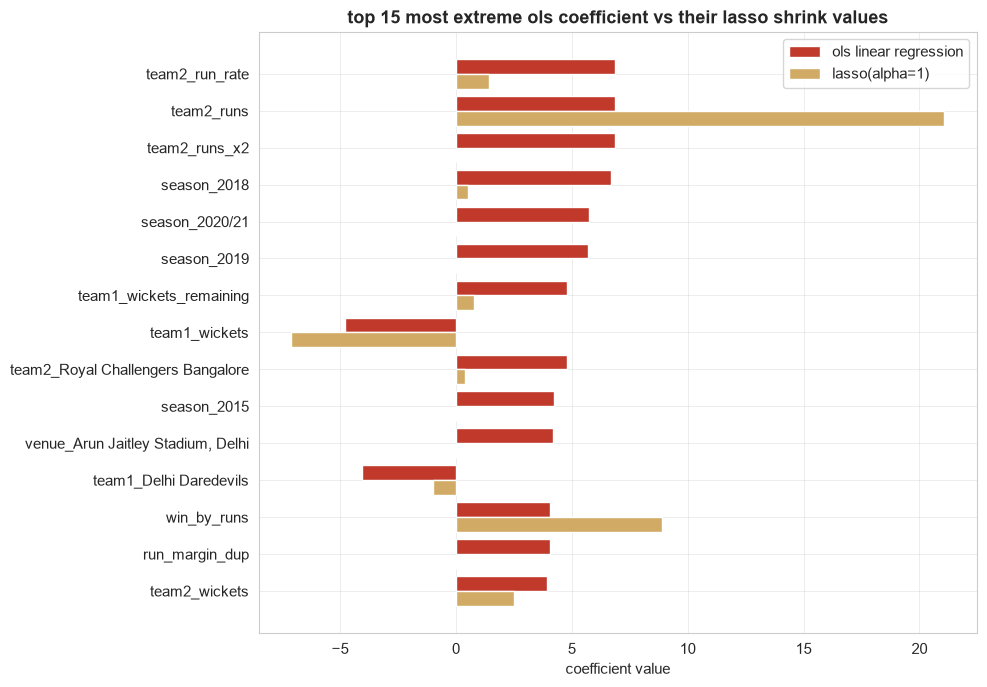

mean |coefficient|-> ols:0.890    lasso:0.163
max |coefficient|-> ols:6.855    lasso:21.074


In [28]:
coef_compare=pd.DataFrame({
    "feature":x.columns,
    "ols_coef":lr.coef_,
    "lasso_coef":lasso_best.coef_,
})
coef_compare["ols_abs"]=coef_compare["ols_coef"].abs()
top_unstable=coef_compare.sort_values("ols_abs",ascending=False).head(15)
fig,ax=plt.subplots(figsize=(10,7))
y_pos=np.arange(len(top_unstable))
ax.barh(y_pos-0.2,top_unstable["ols_coef"],height=0.4,color=MI_RED,label="ols linear regression")
ax.barh(y_pos+0.2,top_unstable["lasso_coef"],height=0.4,color=MI_GOLD,label=f"lasso(alpha=1)")
ax.set_yticks(y_pos)
ax.set_yticklabels(top_unstable["feature"])
ax.set_xlabel("coefficient value")
ax.set_title("top 15 most extreme ols coefficient vs their lasso shrink values",fontweight="bold")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(f"mean |coefficient|-> ols:"
      f"{coef_compare['ols_coef'].abs().mean():.3f}    lasso:{coef_compare['lasso_coef'].abs().mean():.3f}")
print(f"max |coefficient|-> ols:"
      f"{coef_compare['ols_coef'].abs().max():.3f}    lasso:{coef_compare['lasso_coef'].abs().max():.3f}")



In [32]:
summary=pd.DataFrame({
    "model":["linear regression",f"lasso(alpha={1})"],
    "train r2":[lr_train_r2,lasso_train_r2],
    "test r2":[lr_test_r2,lasso_test_r2],
    "train_test_gap":[lr_gap,lasso_gap]
})
print(summary)

               model  train r2   test r2  train_test_gap
0  linear regression  0.856788  0.524902        0.331886
1     lasso(alpha=1)  0.752138  0.610883        0.141255


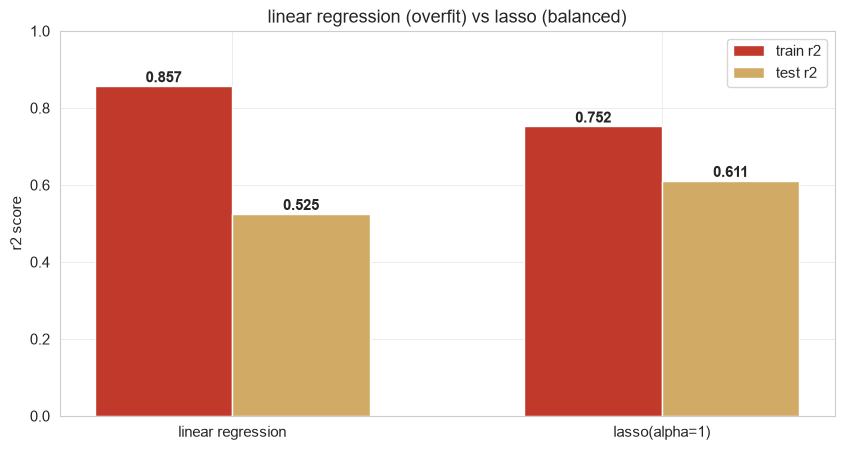

In [35]:
fig,ax=plt.subplots(figsize=(10,5))
x=np.arange(2)
width=0.32
bars1=ax.bar(x-width/2,summary["train r2"],width,label="train r2",color=MI_RED)
bars2=ax.bar(x+width/2,summary["test r2"],width,label="test r2",color=MI_GOLD)
for b in list(bars1) + list(bars2):
    ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.01,f"{b.get_height():.3f}",ha="center",fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(summary["model"])
ax.set_ylim(0,1)
ax.set_ylabel("r2 score")
ax.set_title("linear regression (overfit) vs lasso (balanced)")
ax.legend()
plt.show()